In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from gudhi import SimplexTree
from collections import defaultdict
from persim import PersistenceImager
import persim.images_weights as weights

In [2]:
def compute_circumradius_triangle(p0, p1, p2):
    a = np.linalg.norm(p1 - p2)
    b = np.linalg.norm(p0 - p2)
    c = np.linalg.norm(p0 - p1)
    s = (a + b + c) / 2.0
    area_squared = s * (s - a) * (s - b) * (s - c)
    if area_squared <= 1e-10:
        return max(a, b, c) / 2.0
    return (a * b * c) / (4.0 * np.sqrt(area_squared))


def compute_Cech(points, max_radius=5.0):
    n = len(points)
    st = SimplexTree()
    dist_matrix = squareform(pdist(points))

    for i in range(n):
        st.insert([i], filtration=0.0)

    valid_edges = set()
    for i in range(n):
        for j in range(i + 1, n):
            radius = dist_matrix[i, j] / 2.0
            if radius <= max_radius:
                st.insert([i, j], filtration=radius)
                valid_edges.add((i, j))

    for i, j, k in combinations(range(n), 3):
        if not all((min(a,b), max(a,b)) in valid_edges for a, b in [(i,j), (i,k), (j,k)]):
            continue
        radius = compute_circumradius_triangle(points[i], points[j], points[k])
        if radius <= max_radius:
            st.insert([i, j, k], filtration=radius)

    return st

In [3]:
def divide_filtration(st):
    simplex_filt_pairs = [(tuple(sorted(s)), f) for s, f in st.get_filtration()]
    list_simplex = [pair[0] for pair in simplex_filt_pairs]
    list_filt = [pair[1] for pair in simplex_filt_pairs]
    return list_simplex, list_filt


def _build_boundary(simplices):
    sf_to_idx = {s: i for i, s in enumerate(simplices)}
    boundary = []
    for s in simplices:
        if len(s) <= 1:
            boundary.append(set())
        else:
            rows = set()
            for j in range(len(s)):
                face = s[:j] + s[j+1:]
                if face in sf_to_idx:
                    rows.add(sf_to_idx[face])
            boundary.append(rows)
    return boundary


def _reduce_with_V(columns):
    m = len(columns)
    R = [set(col) for col in columns]
    V = [{i} for i in range(m)]
    low = [-1] * m
    pivot_of_row = {}
    for i in range(m):
        while R[i]:
            li = max(R[i])
            if li in pivot_of_row:
                owner = pivot_of_row[li]
                R[i] ^= R[owner]
                V[i] ^= V[owner]
            else:
                pivot_of_row[li] = i
                low[i] = li
                break
        else:
            low[i] = -1
    return R, low, V

In [4]:
def compute_all_barcodes(A, B, max_radius=5):
    total = np.concatenate([A, B], axis=0)
    a = len(A)

    st = compute_Cech(total, max_radius=max_radius)
    simplices, filt = divide_filtration(st)
    m = len(simplices)

    in_L = [all(v < a for v in s) for s in simplices]
    idx_L = [i for i, b in enumerate(in_L) if b]
    idx_KmL = [i for i, b in enumerate(in_L) if not b]
    set_idx_KmL = set(idx_KmL)
    g2L = {g: pos for pos, g in enumerate(idx_L)}

    Df = _build_boundary(simplices)
    Rf, lowf, Vf = _reduce_with_V(Df)

    boundary_L = []
    for g_idx in idx_L:
        col = {g2L[r] for r in Df[g_idx] if r in g2L}
        boundary_L.append(col)
    Rg, lowg, Vg = _reduce_with_V(boundary_L)

    row_order = idx_L + idx_KmL
    row_remap = {g: i for i, g in enumerate(row_order)}
    inv_row_remap = {i: g for g, i in row_remap.items()}

    Dim = [{row_remap[r] for r in Df[col_idx]} for col_idx in range(m)]
    Rim, lowim, _ = _reduce_with_V(Dim)
    Vim = [{row_remap[r] for r in Vf[col_idx]} for col_idx in range(m)]

    cycle_cols = [i for i in range(m) if not Rim[i]]
    Dker = [Vim[c] for c in cycle_cols]
    if Dker:
        _, lowker, _ = _reduce_with_V(Dker)
    else:
        lowker = []
    cycle_pos = {c: pos for pos, c in enumerate(cycle_cols)}

    Dcok = []
    for i in range(m):
        if in_L[i]:
            jL = g2L[i]
            if not Rg[jL]:
                Dcok.append({idx_L[pos] for pos in Vg[jL]})
                continue
        Dcok.append(set(Df[i]))
    _, lowcok, _ = _reduce_with_V(Dcok)

    def _format_output(bars_dict):
        out = {}
        for p in [0, 1]:
            if p in bars_dict and bars_dict[p]:
                arr = np.array(bars_dict[p])
                out[p] = arr[np.lexsort((arr[:, 1], arr[:, 0]))]
            else:
                out[p] = np.empty((0, 2))
        return out

    image_bars = defaultdict(list)
    for tau in range(m):
        if not Rf[tau] or lowim[tau] == -1:
            continue
        sigma = inv_row_remap[lowim[tau]]
        if sigma in g2L:
            birth_val, death_val = filt[sigma], filt[tau]
            if birth_val != death_val:
                p = len(simplices[sigma]) - 1
                if p >= 0:
                    image_bars[p].append((birth_val, death_val))

    kernel_bars = defaultdict(list)
    for tau in idx_L:
        jL = g2L[tau]
        if not Rg[jL] or Rf[tau] or tau not in cycle_pos:
            continue
        local_col = cycle_pos[tau]
        if local_col >= len(lowker):
            continue
        low_local = lowker[local_col]
        if low_local == -1:
            continue
        sigma = inv_row_remap[low_local]
        if in_L[sigma]:
            continue
        birth_val, death_val = filt[sigma], filt[tau]
        if birth_val != death_val:
            p = len(simplices[sigma]) - 2
            if p >= 0:
                kernel_bars[p].append((birth_val, death_val))

    cok_bars = defaultdict(list)
    for tau in range(m):
        if not Rf[tau] or lowim[tau] == -1:
            continue
        row_global = inv_row_remap[lowim[tau]]
        if row_global not in set_idx_KmL:
            continue
        lowc = lowcok[tau]
        if lowc == -1:
            continue
        sigma = lowc
        birth_val, death_val = filt[sigma], filt[tau]
        if birth_val != death_val:
            p = len(simplices[sigma]) - 1
            if p >= 0:
                cok_bars[p].append((birth_val, death_val))

    return {
        'image': _format_output(image_bars),
        'kernel': _format_output(kernel_bars),
        'cokernel': _format_output(cok_bars)
    }

In [10]:
def compute_Persistence_barcode(A, max_radius=5):
    fil_A = compute_Cech(A, max_radius=max_radius)
    fil_A.persistence()

    bar_A = {}
    for dim in [0, 1]:
        bars = fil_A.persistence_intervals_in_dimension(dim)
        bars = [b for b in bars if b[1] != np.inf and b[1] - b[0] > 1e-5]
        bar_A[dim] = np.array(bars) if bars else np.empty((0, 2))

    return bar_A


def compute_PIs(barcodes, max_eps=10, px_res=0.1, sigma=0.025, normalization=False):
    for key in barcodes:
        if len(barcodes[key]) == 0:
            barcodes[key] = np.zeros((0, 2))

    vector = {}

    pers_imager_h0 = PersistenceImager()
    pers_imager_h0.pixel_size = px_res
    pers_imager_h0.birth_range = (0, 1)
    pers_imager_h0.pers_range = (0, max_eps)
    pers_imager_h0.weight = weights.persistence
    pers_imager_h0.weight_params = {'n': 1}
    pers_imager_h0.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}

    bars_h0 = np.array(barcodes[0])
    if len(bars_h0) > 0:
        img_h0 = pers_imager_h0.transform(bars_h0, skew=False)
    else:
        img_h0 = np.zeros((int(1/px_res), int(max_eps/px_res)))
    img0_1d = np.mean(img_h0, axis=0)

    pers_imager_h1 = PersistenceImager()
    pers_imager_h1.pixel_size = px_res
    pers_imager_h1.birth_range = (0, max_eps)
    pers_imager_h1.pers_range = (0, max_eps / 2)
    pers_imager_h1.weight = weights.persistence
    pers_imager_h1.weight_params = {'n': 1}
    pers_imager_h1.kernel_params = {'sigma': [[sigma, 0], [0, sigma]]}

    bars_h1 = np.array(barcodes[1])
    if len(bars_h1) > 0:
        img_h1 = pers_imager_h1.transform(bars_h1, skew=True)
    else:
        img_h1 = np.zeros((int(max_eps/px_res), int((max_eps/2)/px_res)))

    if normalization:
        vector[0] = img0_1d / np.max(img0_1d) if np.max(img0_1d) > 0 else img0_1d
        vector[1] = img_h1.flatten() / np.max(img_h1) if np.max(img_h1) > 0 else img_h1.flatten()
    else:
        vector[0] = img0_1d
        vector[1] = img_h1.flatten()

    return vector


def visualize_PIs(PIs, max_eps=10, px_res=0.1):
    h0_img = PIs[0]
    h1_img = PIs[1].reshape((int(max_eps / px_res), int((max_eps / 2) / px_res)))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(h0_img, 'b-', linewidth=1.5)
    axes[0].fill_between(range(len(h0_img)), h0_img, alpha=0.3)
    axes[0].set_title('H0 Persistence Image')
    axes[0].set_xlabel('Persistence')
    axes[0].set_ylabel('Intensity')
    axes[0].grid(True, alpha=0.3)

    im = axes[1].imshow(h1_img.T, cmap='hot', origin='lower', aspect='auto')
    axes[1].set_title('H1 Persistence Image')
    axes[1].set_xlabel('Birth')
    axes[1].set_ylabel('Persistence')
    plt.colorbar(im, ax=axes[1])

    plt.tight_layout()
    plt.show()

In [ ]:
A = np.random.rand(120, 2) * 20
B = np.random.rand(80, 2) * 20

In [ ]:
six_pack_A_to_B = compute_all_barcodes(A, B, max_radius=5)
six_pack_B_to_A = compute_all_barcodes(B, A, max_radius=5)

In [7]:
PB_total = compute_Persistence_barcode(np.concatenate([A, B]), max_radius=5)
PB_A = compute_Persistence_barcode(A, max_radius=5)
PB_B = compute_Persistence_barcode(B, max_radius=5)

six_pack_A_to_B.update({'complex': PB_total, 'sub_complex': PB_A, 'relative': PB_B})
six_pack_B_to_A.update({'complex': PB_total, 'sub_complex': PB_B, 'relative': PB_A})

In [11]:
PI_six_pack_A_to_B = {}
for key in ['image', 'kernel', 'cokernel']:
    PI_six_pack_A_to_B[key] = compute_PIs(
        six_pack_A_to_B[key], max_eps=10, px_res=0.1, sigma=0.05, normalization=False
    )

PI_six_pack_B_to_A = {}
for key in ['image', 'kernel', 'cokernel']:
    PI_six_pack_B_to_A[key] = compute_PIs(
        six_pack_B_to_A[key], max_eps=10, px_res=0.1, sigma=0.05, normalization=False
    )

Image (A → B):


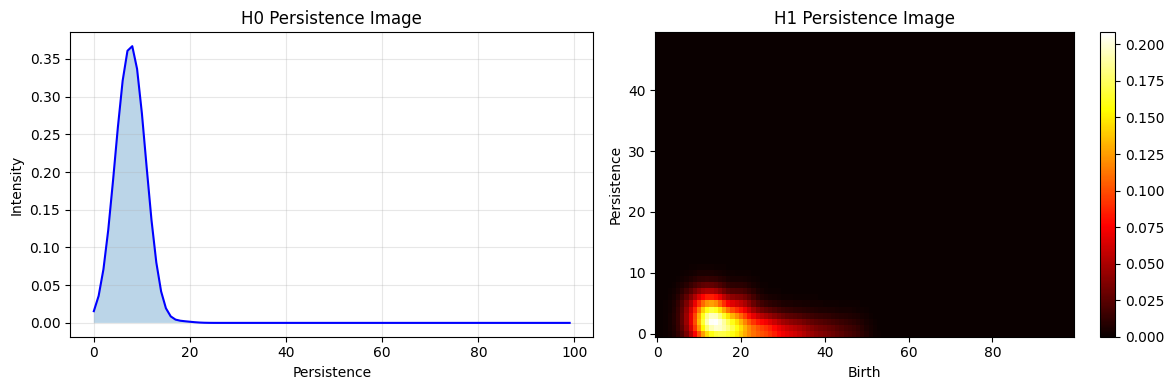

In [14]:
print("Image (A → B):")
visualize_PIs(PI_six_pack_A_to_B['kernel'])